# Active microwave sensing of land
Chapter 21: canopy attenuation, row-direction modulation, and N-look detected-image speckle. All $\sigma^0$ values use linear power units.

In [1]:
import sys
from pathlib import Path

# Support both an installed package and direct execution from this repository.
try:
    import navasar
except ModuleNotFoundError:
    candidates = (Path.cwd(), Path.cwd().parent)
    project_root = next((p for p in candidates if (p / 'navasar').is_dir()), None)
    if project_root is None:
        raise ModuleNotFoundError(
            'NavaSAR is not installed and the repository root was not found. '
            'Run: python -m pip install -e .[notebooks]'
        )
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from navasar.land import canopy_backscatter, linear_to_db, periodic_surface_backscatter, simulate_multilook_intensity
rng = np.random.default_rng(21)
print('Python:', sys.executable)
print('NavaSAR:', navasar.__file__)

Python: /home/mohammad/anaconda3/envs/code/bin/python
NavaSAR: /home/mohammad/Software/NavaSAR/navasar/__init__.py


## Canopy over soil — Eqs. (21.50)–(21.52)
$T^2=\exp(-2\tau\sec\theta)$ and $\sigma^0_{can}=\sigma^0_v+T^2\sigma^0_s$. The optional surface-volume interaction is omitted here.

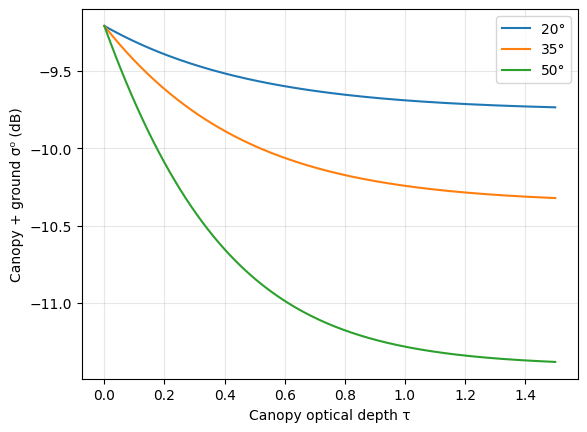

In [2]:
tau = np.linspace(0, 1.5, 250)
for angle in (20, 35, 50):
    sigma0 = canopy_backscatter(0.12, tau, albedo=0.15, theta_inc_deg=angle)
    plt.plot(tau, linear_to_db(sigma0), label=f'{angle}°')
plt.xlabel('Canopy optical depth τ'); plt.ylabel('Canopy + ground σ⁰ (dB)')
plt.legend(); plt.grid(alpha=.3);

## Periodic agricultural rows — Eq. (21.37)
The facet integral needs a small-scale backscatter law. This Gaussian angular law is illustrative; replace it with a validated rough-surface model for quantitative work.

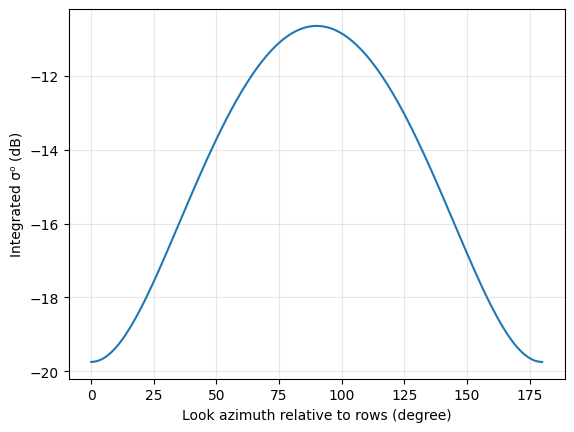

In [3]:
def illustrative_local_law(theta_deg):
    return 0.25 * np.exp(-(theta_deg / 22.0)**2)
azimuth = np.linspace(0, 180, 181)
row_sigma0 = np.array([periodic_surface_backscatter(
    illustrative_local_law, theta_inc_deg=35, look_azimuth_deg=phi,
    amplitude=0.055, wavelength=0.606) for phi in azimuth])
plt.plot(azimuth, linear_to_db(row_sigma0))
plt.xlabel('Look azimuth relative to rows (degree)'); plt.ylabel('Integrated σ⁰ (dB)')
plt.grid(alpha=.3);

## Synthetic land scene and N-look fading
Gamma fading has unit mean and variance $1/N$, consistent with the Chapter 21 intensity model. This is a detected image, not a phase-preserving SLC.

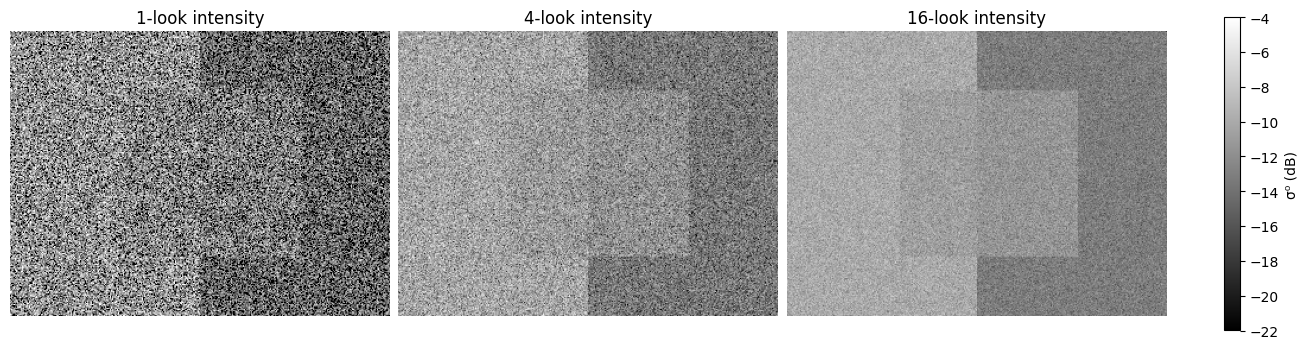

In [4]:
ny, nx = 240, 320
surface = np.full((ny, nx), 0.035); surface[:, :nx//2] = 0.11
tau_map = np.full((ny, nx), 0.15); tau_map[50:190, 95:245] = 0.75
mean_scene = canopy_backscatter(surface, tau_map, albedo=0.13, theta_inc_deg=35)
images = [simulate_multilook_intensity(mean_scene, n, rng=rng) for n in (1, 4, 16)]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, image, n in zip(axes, images, (1, 4, 16)):
    im = ax.imshow(linear_to_db(image, floor_db=-30), cmap='gray', vmin=-22, vmax=-4)
    ax.set_title(f'{n}-look intensity'); ax.axis('off')
fig.colorbar(im, ax=axes, label='σ⁰ (dB)', shrink=.8);